## **신도시 아파트 가격 예측 (LinearRegression)**

- 과거의 신도시 아파트 거래 데이터를 훈련 세트로 활용하여 **신검단중앙역금강펜테리움센트럴파크** 아파트의 가격을 예측하고 실제 현재 거래금액과 비교


#### **0. 라이브러리 임포트**

In [15]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# 한글 폰트 설정
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

print("라이브러리 임포트 완료")

라이브러리 임포트 완료


#### **1. 데이터 불러오기**

In [16]:
# 경로 설정
train_folder = r"C:\3_1_DataMining\팀 프로젝트\신도시 데이터\new_city.csv"
test_folder  = r"C:\3_1_DataMining\팀 프로젝트\geomdan_merged.csv"

df_all  = pd.read_csv(train_folder ,     encoding='utf-8-sig')
df_test = pd.read_csv(test_folder  , encoding='utf-8-sig')

# 훈련 데이터 설정
df_train = df_all[df_all['도시명'].isin(['광교', '판교', '운정'])].copy()


#### **2. 데이터 전처리**

- **2-1. 거래금액 숫자 변환**

In [17]:
df_train['거래금액(만원)'] = df_train['거래금액(만원)'].str.replace(',', '').astype(int)
df_test['거래금액(만원)']  = df_test['거래금액(만원)'].str.replace(',', '').astype(int)

print("거래금액 변환 완료")
print(df_train['거래금액(만원)'].describe().apply(lambda x: f'{x:,.0f}'))

거래금액 변환 완료
count     36,180
mean      62,858
std       46,129
min       11,000
25%       32,315
50%       46,000
75%       75,000
max      490,000
Name: 거래금액(만원), dtype: str


- **2-2. ㎡당 가격 파생변수 생성**

In [18]:
df_train['m2당가격'] = df_train['거래금액(만원)'] / df_train['전용면적(㎡)']
df_test['m2당가격']  = df_test['거래금액(만원)']  / df_test['전용면적(㎡)']

print("훈련 데이터 m2당가격 :")
print(df_train['m2당가격'].describe().round(2))

훈련 데이터 m2당가격 :
count    36180.00
mean       695.30
std        460.79
min        166.82
25%        370.21
50%        522.21
75%        853.88
max       3653.53
Name: m2당가격, dtype: float64


- **2-3. 발표 후 경과년수 필터링**

In [19]:
df_train = df_train[df_train['발표후경과년수'] >= 3]
df_test  = df_test[df_test['발표후경과년수'] >= 3]

print(f"필터링 후 훈련 데이터:   {len(df_train):,}건")
print(f"필터링 후 테스트 데이터: {len(df_test):,}건")

필터링 후 훈련 데이터:   36,180건
필터링 후 테스트 데이터: 31,751건


- **2-4. 훈련 데이터 연도 제한 및 검단 데이터 합산**

In [20]:
df_train         = df_train[df_train['계약연도'] <= 2022]
df_geomdan_train = df_test[df_test['계약연도'] <= 2022].copy()

df_train = pd.concat([df_train, df_geomdan_train], ignore_index=True)

print(f"훈련 데이터 (광교·판교·운정 + 검단 2022 이하): {len(df_train):,}건")

훈련 데이터 (광교·판교·운정 + 검단 2022 이하): 51,411건


- **2-5. 이상치 제거 (z-score)**

In [21]:
# ── 이상치 제거 ──
df_train = df_train[df_train['전용면적(㎡)'] >= 33]
print(f"이상치 제거 전 데이터 건수: {len(df_train)}")

# 전용면적 33제곱미터 미만 제거 (논문 기준: 거래 빈도 낮고 가격 편차 심함)
df_train = df_train[df_train['전용면적(㎡)'] >= 33]
print(f"전용면적 33㎡ 미만 제거 후: {len(df_train)}")

# 거래금액 z-score 기준 이상치 제거 (|z| > 2인 데이터 제거)
mean = df_train['m2당가격'].mean()
std = df_train['m2당가격'].std()
z_scores = (df_train['m2당가격'] - mean) / std
df_train = df_train[z_scores.abs() <= 2]
print(f"z-score 이상치 제거 후: {len(df_train)}")

print(f"훈련 데이터: {len(df_train)}건")
print(f"테스트 데이터: {len(df_test)}건")

이상치 제거 전 데이터 건수: 51296
전용면적 33㎡ 미만 제거 후: 51296
z-score 이상치 제거 후: 48440
훈련 데이터: 48440건
테스트 데이터: 31751건


#### **3. 입력 변수, 타겟 변수 설정**

In [22]:
features = [
    '건축년도', '층',
    '지하철호선개수', '기차역까지의거리',
    '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
    '발표후경과년수', 'CPI', '계약연도',
    '서울도심거리', '단지별_세대수', '도시별_세대수'
]

# 결측치 제거
df_train = df_train.dropna(subset=features + ['m2당가격'])

train_input  = df_train[features]
train_target = df_train['m2당가격']

print(f"훈련 세트 크기: {train_input.shape}")

훈련 세트 크기: (48440, 12)


#### **4. 특성 표준화 (StandardScaler)**

In [23]:
ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)

print("표준화 완료")
print(f"train_scaled 평균     (첫 번째 특성): {train_scaled[:, 0].mean():.4f}")
print(f"train_scaled 표준편차 (첫 번째 특성): {train_scaled[:, 0].std():.4f}")

표준화 완료
train_scaled 평균     (첫 번째 특성): -0.0000
train_scaled 표준편차 (첫 번째 특성): 1.0000


#### **5. 선형 회귀 모델 학습**

In [24]:
# 모델 객체 생성
model = LinearRegression()

# 모델 학습
model.fit(train_scaled, train_target)

print("선형 회귀 모델 학습 완료")
print(f"훈련 세트 R²: {model.score(train_scaled, train_target):.4f}")

선형 회귀 모델 학습 완료
훈련 세트 R²: 0.8124


#### **5. 회귀 계수 확인**

In [25]:
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("회귀 계수 (절댓값 내림차순):")
display(coef_df.reset_index(drop=True))
print(f"\n절편 (intercept): {model.intercept_:.4f}")

회귀 계수 (절댓값 내림차순):


,Feature,Coefficient
0,계약연도,243.237997
1,발표후경과년수,-197.367557
2,도시별_세대수,-190.178340
3,건축년도,51.493566
4,서울도심거리,-32.234175
5,지하철호선개수,31.902017
6,CPI,-26.495804
7,단지별_세대수,22.186833
8,가장 가까운 지하철역까지의 거리,-11.169991
9,층,7.876380



절편 (intercept): 403.4686


#### **6. 회귀 계수 시각화**

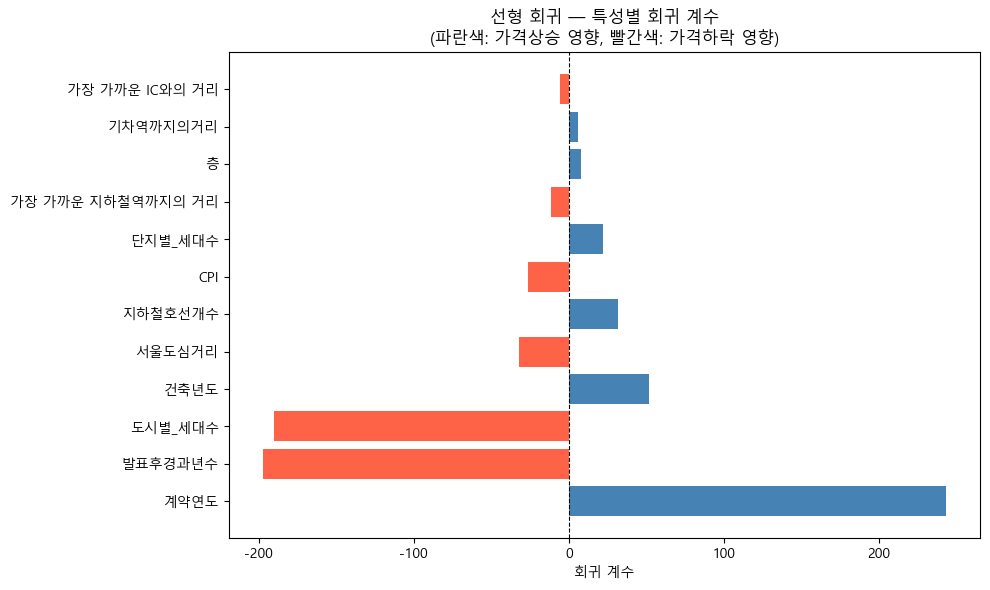

In [26]:
plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('회귀 계수')
plt.title('선형 회귀 — 특성별 회귀 계수\n(파란색: 가격상승 영향, 빨간색: 가격하락 영향)')
plt.tight_layout()
plt.show()

#### **7. 모델 검증 — 신검단중앙역금강펜테리움센트럴파크 (2026년)**

In [27]:

금강_기본 = {
    '건축년도'                     : 2025,
    '층'                           : 12,
    '지하철호선개수'                : 3,
    '기차역까지의거리'              : 16.7135,
    '가장 가까운 지하철역까지의 거리': 0.894,
    '가장 가까운 IC와의 거리'       : 5.804,
    '발표후경과년수'                : 20,
    'CPI'                          : 116.61,
    '계약연도'                     : 2026,
    '서울도심거리'                  : 25.136,
    '단지별_세대수'                 : 1049.0,
    '도시별_세대수'                 : 60833.0,
}

면적_검증    = 86.23
실제_거래금액 = 52093

입력        = pd.DataFrame([금강_기본])[features]
입력_scaled  = ss.transform(입력)
예측_m2      = model.predict(입력_scaled)[0]
예측_거래금액 = int(예측_m2 * 면적_검증)
오차율       = abs(예측_거래금액 - 실제_거래금액) / 실제_거래금액 * 100

print(f"{chr(61)*60}")
print(f"모델 검증: 신검단중앙역금강펜테리움센트럴파크 (2026년, 38건 평균)")
print(f"{chr(61)*60}")
print(f"실제 거래금액 (평균): {실제_거래금액:,}만원  ({실제_거래금액/10000:.1f}억)")
print(f"예측 거래금액       : {예측_거래금액:,}만원  ({예측_거래금액/10000:.1f}억)")
print(f"오차               : {예측_거래금액 - 실제_거래금액:+,}만원")
print(f"오차율             : {오차율:.1f}%")

모델 검증: 신검단중앙역금강펜테리움센트럴파크 (2026년, 38건 평균)
실제 거래금액 (평균): 52,093만원  (5.2억)
예측 거래금액       : 54,703만원  (5.5억)
오차               : +2,610만원
오차율             : 5.0%


#### **8. 실제 vs 예측 시각화**

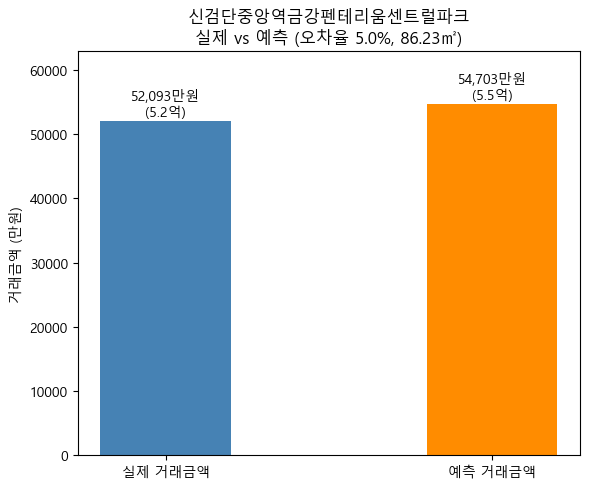

In [28]:
labels  = ['실제 거래금액', '예측 거래금액']
values  = [실제_거래금액, 예측_거래금액]
colors  = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, values, color=colors, width=0.4)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f'{val:,}만원\n({val/10000:.1f}억)',
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('거래금액 (만원)')
ax.set_title(f'신검단중앙역금강펜테리움센트럴파크\n실제 vs 예측 (오차율 {오차율:.1f}%, 86.23㎡)')
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()